<a href="https://colab.research.google.com/github/iespinozahDM/UBA-DM/blob/main/Clase_02_pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
pd.__version__

# Crear, leer y escribir datos

### Crear datos

In [ ]:
pd.Series([100, 210, 320, 456], name="Ventas")

In [ ]:
s = pd.Series([100, 210, 320, 456], name="Ventas", index=["ventas 2020", "ventas 2021", "ventas 2022", "ventas 2023"])
s

In [ ]:
s["ventas 2022"]

In [ ]:
df = pd.DataFrame({
    "ventas 2021": [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200],
    "ventas 2022": [110, 210, 310, 410, 510, 610, 710, 810, 910, 1010, 1110, 1210],
}, index=["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"])
df

In [ ]:
df.loc["Mar":"Oct", "ventas 2021"]

## Leer datos


In [42]:
fn = "https://data.insideairbnb.com/argentina/ciudad-aut%C3%B3noma-de-buenos-aires/buenos-aires/2025-01-29/visualisations/listings.csv"
df = pd.read_csv(fn, index_col="id")
df

,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
id,,,,,,,,,,,,,,,,,
11508,Amazing Luxurious Apt-Palermo Soho,42762,Candela,NaN,Palermo,-34.581840,-58.424150,Entire home/apt,67518.0,3,44,2025-01-26,0.29,1,300,5,NaN
14222,"RELAX IN HAPPY HOUSE - PALERMO, BUENOS AIRES",87710233,María,NaN,Palermo,-34.586170,-58.410360,Entire home/apt,22375.0,7,123,2025-01-18,0.80,6,44,8,NaN
15074,ROOM WITH RIVER SIGHT,59338,Monica,NaN,Nuñez,-34.538920,-58.465990,Private room,NaN,29,0,NaN,NaN,1,0,0,NaN
16695,DUPLEX LOFT 2 - SAN TELMO,64880,Elbio Mariano,NaN,Monserrat,-34.614390,-58.376110,Entire home/apt,52511.0,2,45,2019-11-30,0.27,9,365,0,NaN
20062,PENTHOUSE /Terrace & pool /City views /2bedrooms,75891,Sergio,NaN,Palermo,-34.581848,-58.441605,Entire home/apt,113360.0,2,330,2025-01-17,1.84,4,209,25,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1343797906145861177,Moderno departamento 1 amb dividido balcón,246385359,Marcela Karina,NaN,Villa Pueyrredon,-34.584077,-58.497374,Entire home/apt,47260.0,3,0,NaN,NaN,9,365,0,NaN
1343805212193119512,Amplias Habitaciones con Terraza en Palermo Soho,450612472,Miguel,NaN,Palermo,-34.588779,-58.433459,Private room,46210.0,1,0,NaN,NaN,19,364,0,NaN
1343811295921195058,Loft para 6 personas en Palermo Soho -o82,14450833,Alejandro,NaN,Palermo,-34.581023,-58.425769,Entire home/apt,36243.0,1,0,NaN,NaN,88,351,0,NaN


In [ ]:
# primeras y últimas 5 filas
df.head()
df.tail()

In [ ]:
# número de filas y columnas
df.shape

In [ ]:
# columnas de un dataframe
df.columns

In [43]:
df.to_csv('listados_baires.csv')

## Indexar, seleccionar y modificar datos

In [ ]:
# # leer una columna (es una serie) -- forma medio truchita
df.room_type

In [ ]:
# leer una columna (es una serie) -- forma preferida
df["room_type"]

In [ ]:
# es por esto la preferencia
c = "room_type"
df[c]

In [ ]:
# dataframe de 2 columnas
df[["room_type", "price"]]

In [ ]:
# dataframe de 1 columna
df[["room_type"]]

## Indexación

In [21]:
# acceder a la fila 1
df.iloc[0] #el registro q ocupa la posición N
#df.head(1) muestra los primeros N registros

,11508
name,Amazing Luxurious Apt-Palermo Soho
host_id,42762
host_name,Candela
neighbourhood_group,NaN
neighbourhood,Palermo
latitude,-34.58184
longitude,-58.42415
room_type,Entire home/apt
price,67518.0
minimum_nights,3


In [23]:
# acceder a la fila 1, columna 0
df.iloc[0, 0]

'Amazing Luxurious Apt-Palermo Soho'

In [24]:
# filas 3 a 9, columnas 0 a 1
df.iloc[3:10, 0:2] #3:10 muestra hasta la fila 9

,name,host_id
id,,
16695,DUPLEX LOFT 2 - SAN TELMO,64880
20062,PENTHOUSE /Terrace & pool /City views /2bedrooms,75891
20429,Hermoso y acogedor departamento.,77065
24713,"BEAUTIFUL, EXCELLENT UBICATION/OBELISK 5 STAR...",100743
24763,Amazing LOFTpalermo: contemporary and cool,101049
27631,"Departamento en Vicente López y Callao, Recoleta",119446
29990,"Funky & Stylish Apartment, Palermo",129245


In [25]:
df.loc[14222:20062, ["room_type", "price"]]

,room_type,price
id,,
14222,Entire home/apt,22375.0
15074,Private room,NaN
16695,Entire home/apt,52511.0
20062,Entire home/apt,113360.0


## Seleccion condicional

In [26]:
df["room_type"] == "Private room"

,room_type
id,
11508,False
14222,False
15074,True
16695,False
20062,False
...,...
1343797906145861177,False
1343805212193119512,True
1343811295921195058,False


In [27]:
df.loc[df["room_type"] == "Private room", ["neighbourhood", "room_type"]]

,neighbourhood,room_type
id,,
15074,Nuñez,Private room
93174,Balvanera,Private room
96490,Palermo,Private room
131145,Almagro,Private room
143173,Balvanera,Private room
...,...,...
1340964958529234363,San Telmo,Private room
1340968806949853975,San Telmo,Private room
1341375711362338850,Monserrat,Private room


In [28]:
f = (df.price > 20) & (df.neighbourhood == "Chacarita")  # condicion que debe dar como resultado TRUE
df.loc[f, ["neighbourhood", "room_type"]]                # Mostrar en el df los registros q hayan dado como resultado true

,neighbourhood,room_type
id,,
24763,Chacarita,Entire home/apt
589147,Chacarita,Private room
644840,Chacarita,Entire home/apt
702905,Chacarita,Entire home/apt
780906,Chacarita,Entire home/apt
...,...,...
1330764891084410714,Chacarita,Entire home/apt
1330772673206772143,Chacarita,Entire home/apt
1331254791475105364,Chacarita,Private room


In [29]:
f = (df.price > 20) & ((df.neighbourhood == "Chacarita") | (df.neighbourhood == "Palermo"))
# f = (df.price > 20) & (df.neighbourhood.isin(["Chacarita", "Palermo"])) # equivalente a lo anterior, para un OR mayor
df.loc[f, ["neighbourhood", "room_type"]]

,neighbourhood,room_type
id,,
11508,Palermo,Entire home/apt
14222,Palermo,Entire home/apt
20062,Palermo,Entire home/apt
24763,Chacarita,Entire home/apt
29990,Palermo,Entire home/apt
...,...,...
1343773068940841853,Palermo,Entire home/apt
1343793717013928063,Palermo,Private room
1343794664096692898,Palermo,Entire home/apt


In [33]:
# Ejercicio: quiero los nombres de los host que alquilan habitaciones compartidas en Núñez
f = (df.neighbourhood == 'Belgrano') & (df.room_type == 'Shared room')
df.loc[f, "host_name"]

,host_name
id,
48050062,Raquel
845887224994436428,Paula
847993175387300969,Paula


In [39]:
# Ejercicio: Cuántos Private Rooms hay listados en Lugano?
f = (df.neighbourhood == 'Villa Lugano') & (df.room_type == 'Private room')
df.loc[f, "host_name"].shape[0]

3

## Modificación de datos

In [44]:
df["number_of_reviews"]
#df["number_of_reviews"] = 10 → asigna una constante
#df["number_of_reviews"] = df["number_of_reviews"] + 10 → suma una constante a todos los valores

,number_of_reviews
id,
11508,44
14222,123
15074,0
16695,45
20062,330
...,...
1343797906145861177,0
1343805212193119512,0
1343811295921195058,0


In [ ]:
f = (df.neighbourhood == 'Palermo') & (df.room_type == 'Shared room')
# aumentar el precio 10%
df.loc[f, "price"] = df.loc[f, "price"] * 1.10

In [ ]:
df.loc[df["host_name"] == "Nacho", "host_name"] = "Ignacio"

## Crear campos

In [52]:
df["es_caro"] = False

f = (df.neighbourhood == 'Nuñez') & (df.price > 100)
df.loc[f, "es_caro"] = True


## Funciones de resúmen

In [ ]:
df.price.mean()
df.price.std()
df.price.var()
df.price.min()
df.price.max()
df.price.sum()

In [ ]:
df.price.describe()

In [ ]:
df.room_type.describe()

In [ ]:
df.room_type.unique()

In [ ]:
df.room_type.value_counts()

In [ ]:
# valores perdidos
df.host_name.isna().sum()
df.host_name.notna().sum()

In [ ]:
for c in df.columns:
    print(c, df[c].isna().sum(), df[c].notna().sum())

## Funciones de mapeo

In [ ]:
df.room_type.unique()

In [54]:
#df.loc[df.room_type == 'Entire home/apt', "room_type"] = 'E' ## forma sanguinaria

m = {
    'Entire home/apt': 'E',
    'Private room': 'P',
    'Hotel room': 'H',
    'Shared room': 'S'
}

df.room_type.map(m)

,room_type
id,
11508,E
14222,E
15074,P
16695,E
20062,E
...,...
1343797906145861177,E
1343805212193119512,P
1343811295921195058,E


In [58]:
precio_medio = df.price.mean()

def distancia_a_la_media(p):
    if (p > 100):
        return p - precio_medio
    else:
        return p

df.price.apply(distancia_a_la_media)

### NOOOOOOOOOO OOO OO OOOOO OOOOOO
#for p in df.price:
#    distancia_a_la_media(p)

,price
id,
11508,-27969.76489
14222,-73112.76489
15074,NaN
16695,-42976.76489
20062,17872.23511
...,...
1343797906145861177,-48227.76489
1343805212193119512,-49277.76489
1343811295921195058,-59244.76489


## Tipos de datos

In [59]:
df.dtypes

,0
name,object
host_id,int64
host_name,object
neighbourhood_group,float64
neighbourhood,object
latitude,float64
longitude,float64
room_type,object
price,float64
minimum_nights,int64


In [60]:
df.price.dtype

dtype('float64')

In [61]:
df.number_of_reviews.astype('int32')

,number_of_reviews
id,
11508,44
14222,123
15074,0
16695,45
20062,330
...,...
1343797906145861177,0
1343805212193119512,0
1343811295921195058,0


In [ ]:
fn = "https://data.insideairbnb.com/argentina/ciudad-aut%C3%B3noma-de-buenos-aires/buenos-aires/2025-01-29/visualisations/listings.csv"
df = pd.read_csv(fn, index_col="id", dtype={"number_of_reviews": "uint16"})
df.number_of_reviews

## Valores perdidos

In [ ]:
# saber cuantos valores perdidos tiene host_name
df.host_name.isna().sum()

In [53]:
# imputar los valores perdidos -- forma artesanal
df.loc[df.host_name.isna(), "host_name"] = "desconocido"

In [ ]:
# imputar los valores perdidos -- forma cool
df.host_name = df.host_name.fillna("desconocido")
# df.host_name.fillna("desconocido", inplace=True) # equivalente al anterior

## Funciones de string

In [ ]:
df.name.str.lower().str.contains("jacuzzi")

## Agrupamiento y ordenamiento de datos

In [62]:
df["neighbourhood"].value_counts()

,count
neighbourhood,
Palermo,11410
Recoleta,5105
San Nicolas,2363
Belgrano,1832
Retiro,1667
Monserrat,1646
Almagro,1312
Balvanera,1279
Villa Crespo,1200


In [63]:
df.groupby("neighbourhood").price.mean()

,price
neighbourhood,
Agronomia,3.396863e+04
Almagro,8.515188e+04
Balvanera,1.309248e+05
Barracas,6.142961e+04
Belgrano,7.870404e+04
Boca,2.262417e+05
Boedo,3.265716e+04
Caballito,4.443621e+04
Chacarita,4.436621e+04


In [64]:
df.groupby("neighbourhood").price.agg(["min", "max", "mean", "std"])

,min,max,mean,std
neighbourhood,,,,
Agronomia,6000.0,74475.0,3.396863e+04,1.430560e+04
Almagro,5200.0,47259767.0,8.515188e+04,1.399686e+06
Balvanera,1149.0,43292064.0,1.309248e+05,1.679789e+06
Barracas,2818.0,1050217.0,6.142961e+04,1.053172e+05
Belgrano,600.0,36757596.0,7.870404e+04,9.188071e+05
Boca,6000.0,21004341.0,2.262417e+05,1.939428e+06
Boedo,5000.0,141779.0,3.265716e+04,1.958049e+04
Caballito,650.0,672139.0,4.443621e+04,5.280047e+04
Chacarita,8402.0,382132.0,4.436621e+04,3.924332e+04


In [65]:
df.groupby(["neighbourhood", "room_type"]).price.agg(["min", "max", "mean", "std"])


min         max          mean  \
neighbourhood    room_type                                            
Agronomia        Entire home/apt  21908.0     74475.0  37856.379310   
                 Private room      6000.0     21004.0  15177.833333   
Almagro          Entire home/apt   5200.0  47259767.0  94034.693079   
                 Private room      7352.0    525109.0  25968.385185   
                 Shared room      10502.0     14703.0  12952.833333   
...                                   ...         ...           ...   
Villa Santa Rita Private room     33607.0     33607.0  33607.000000   
Villa Soldati    Entire home/apt  24008.0     24008.0  24008.000000   
                 Private room         NaN         NaN           NaN   
Villa Urquiza    Entire home/apt   1800.0    540116.0  45638.060345   
                 Private room     12603.0    525109.0  48648.700000   

                                           std  
neighbourhood    room_type                      
Agronomia        Entire home/apt  1.234355e+04  
                 Private room     5.197074e+03  
Almagro          Entire home/apt  1.499127e+06  
                 Private room     4.477680e+04  
                 Shared room      1.507551e+03  
...                                        ...  
Villa Santa Rita Private room              NaN  
Villa Soldati    Entire home/apt           NaN  
                 Private room              NaN  
Villa Urquiza    Entire home/apt  4.890447e+04  
                 Private room     1.128511e+05  

[124 rows x 4 columns]

In [66]:
df.groupby(["neighbourhood", "room_type"]).price.agg(["min", "max", "mean", "std"]).reset_index()

,neighbourhood,room_type,min,max,mean,std
0,Agronomia,Entire home/apt,21908.0,74475.0,37856.379310,1.234355e+04
1,Agronomia,Private room,6000.0,21004.0,15177.833333,5.197074e+03
2,Almagro,Entire home/apt,5200.0,47259767.0,94034.693079,1.499127e+06
3,Almagro,Private room,7352.0,525109.0,25968.385185,4.477680e+04
4,Almagro,Shared room,10502.0,14703.0,12952.833333,1.507551e+03
...,...,...,...,...,...,...
119,Villa Santa Rita,Private room,33607.0,33607.0,33607.000000,NaN
120,Villa Soldati,Entire home/apt,24008.0,24008.0,24008.000000,NaN
121,Villa Soldati,Private room,NaN,NaN,NaN,NaN
122,Villa Urquiza,Entire home/apt,1800.0,540116.0,45638.060345,4.890447e+04


In [67]:
df.sort_values(by=["host_name", "neighbourhood"], ascending=[True, False])

,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,es_caro
id,,,,,,,,,,,,,,,,,,
33043157,Hotel 725 Continental - Hab Doble con desayuno,242944601,725 Continental Hotel,NaN,San Nicolas,-34.606760,-58.377510,Hotel room,NaN,1,1,2019-09-16,0.02,2,0,0,NaN,False
35251230,Hotel 725 Continental - Hab. Doble sin desayuno,242944601,725 Continental Hotel,NaN,San Nicolas,-34.606540,-58.377830,Hotel room,NaN,1,0,NaN,NaN,2,0,0,NaN,False
1254578514243282813,Palermo Hollywood apartamento barato para grupos,203507346,@Bar.Palladino,NaN,Palermo,-34.583080,-58.434300,Entire home/apt,31118.0,1,10,2025-01-16,3.09,1,353,10,NaN,False
866063432708071927,Luna de San Telmo B,5564636,A.,NaN,Barracas,-34.627240,-58.372390,Entire home/apt,46661.0,21,6,2024-12-29,0.39,7,114,3,NaN,False
866732247857056030,Luna de San Telmo A,5564636,A.,NaN,Barracas,-34.627584,-58.374031,Entire home/apt,94520.0,7,14,2025-01-06,0.66,7,255,8,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14839237,Bright with two bedrooms & a terrace,24335473,Éric,NaN,Almagro,-34.603490,-58.415630,Entire home/apt,42714.0,7,14,2023-12-26,0.15,3,291,0,NaN,False
16186865,Новый дуплекс в Палермо Голливуд,66730566,Анна,NaN,Palermo,-34.586784,-58.440992,Entire home/apt,NaN,2,0,NaN,NaN,1,0,0,NaN,False
1182099976094316953,3 amb vista a parque,479390607,Катя,NaN,Balvanera,-34.611270,-58.397630,Entire home/apt,63013.0,3,0,NaN,NaN,1,90,0,NaN,False


In [70]:
# Hosts con más de 10 opiniones en total
g = df.groupby(by="host_name")["number_of_reviews"].agg("sum").reset_index()
g.loc[g.number_of_reviews > 10]

,host_name,number_of_reviews
2,A.,46
3,ALe,142
4,ALejandra,20
7,Abel,18
8,Abelardo,274
...,...,...
4335,Zulma,191
4336,Zulma Elizabeth,15
4337,desconocido,253
4339,Ángel,4140


## Gráficos

<Axes: >

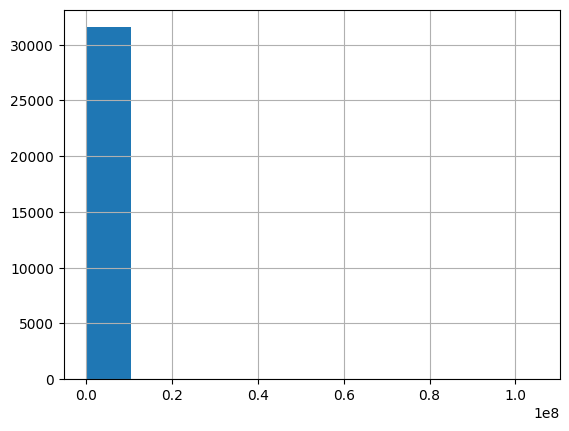

In [73]:
df.price.hist(bins=10)

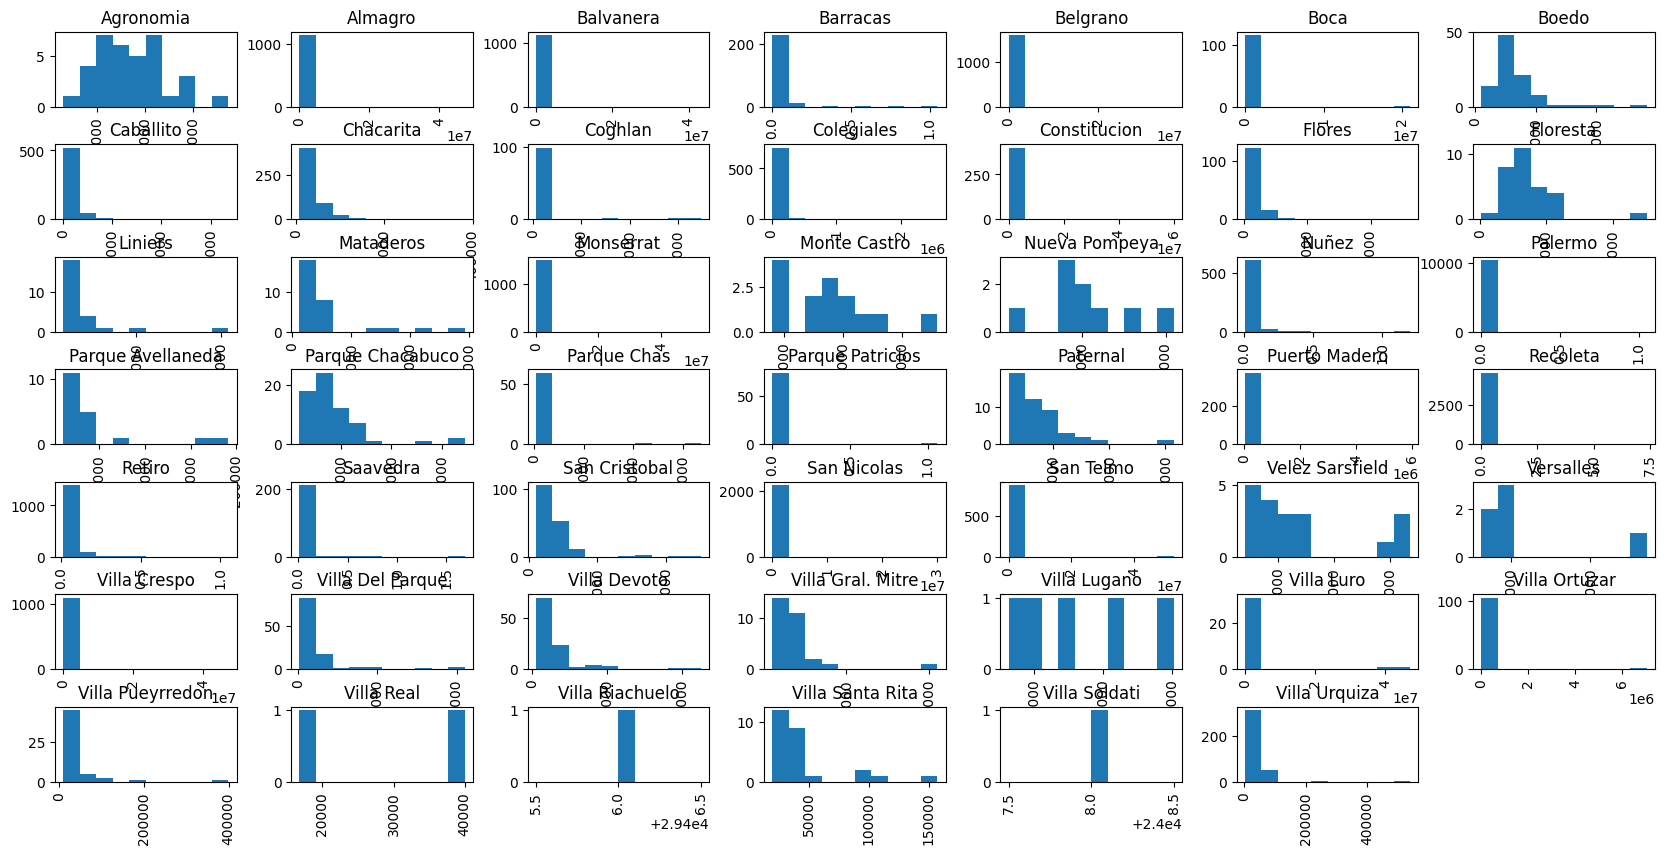

In [74]:
df.hist(by="neighbourhood", column="price", figsize=(20, 10));

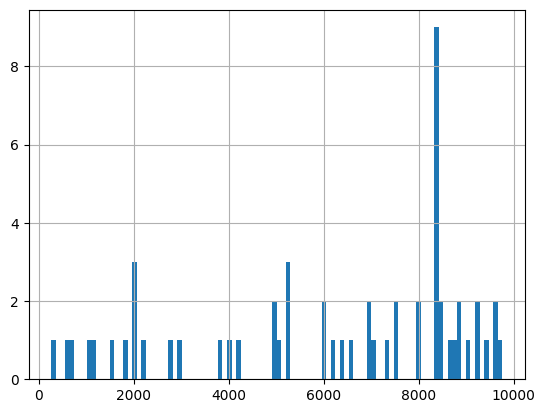

In [75]:
df.loc[df["price"] < 10000, "price"].hist(bins=100);

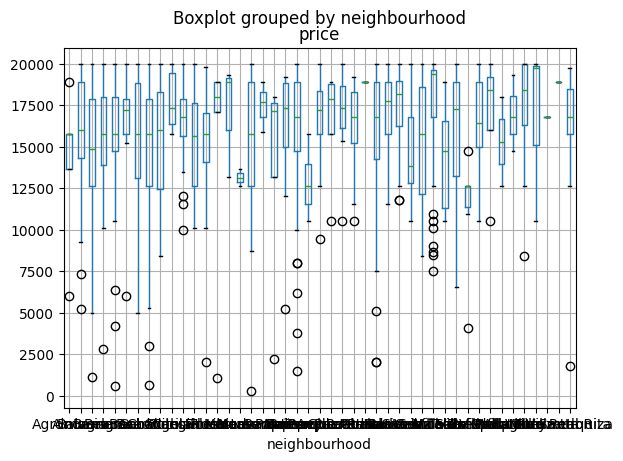

In [76]:
#df[df.price < 20000].boxplot(column="price");
df[df.price < 20000].boxplot(by="neighbourhood", column="price");

In [ ]:
df.loc[df["price"] < 2000].plot.scatter("price", "number_of_reviews")

In [ ]:
df.plot.scatter("longitude", "latitude")

## Trabajo en Clase: Análisis de Consumo de Energía

**Desafío**: Analizar un dataset de consumo energético para identificar patrones de uso.

**Instrucciones**:
1. **Preparación**: Ejecuta la celda de abajo para generar el dataset `consumo_energia_hogar.csv` localmente.
2. **Carga**: Leer el archivo CSV y mostrar las primeras 10 filas.
   - *Tip: Usa `pd.read_csv('nombre_archivo.csv')`.*
3. **Cálculo**: Crear una nueva columna llamada `consumo_total` que sea la suma de `electrodomesticos` e `iluminacion`.
   - *Tip: Podes sumar columnas directamente como `df['col1'] + df['col2']`.*
4. **Cálculo 2**: Crear una nueva columna llamada `consumo_normalizado` que sea `consumo_total` dividido la media de dicha columna.
   - *Tip: Podes operar con calculos directamente así `df['col1'] / df['col1'].mean()`*
5. **Filtro**: Filtrar el DataFrame para mostrar solo los registros donde el `consumo_total` sea superior al promedio.
   - *Tip: Primero calcula el promedio con `.mean()` y luego úsalo para filtrar con `df[df['col'] > promedio]`.*
6. **Agregación**: Agrupar por la columna `dia_semana` y calcular el consumo promedio diario.
   - *Tip: Usa `.groupby('columna').consumo_total.mean()`.*
7. **Visualización**: Generar un gráfico de barras que muestre el consumo promedio por día.
   - *Tip: Agrega `.plot.bar()` al final de tu agrupación.*

**Resultado esperado**: Un DataFrame filtrado por consumo alto y un gráfico de barras que identifique el día de mayor consumo promedio.

In [ ]:
import numpy as np

# 1. Generación de datos sintéticos para el ejercicio
np.random.seed(42)
dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
data = {
    'dia_semana': np.random.choice(dias, 100),
    'electrodomesticos': np.random.uniform(1.0, 5.0, 100).round(2),
    'iluminacion': np.random.uniform(0.1, 0.8, 100).round(2)
}
df_consumo = pd.DataFrame(data)
df_consumo.to_csv('consumo_energia_hogar.csv', index=False)
print("Archivo 'consumo_energia_hogar.csv' generado correctamente.")

In [ ]:
# 2. Cargar el archivo 'consumo_energia_hogar.csv'

# 3. Calcular la nueva columna

# 4. Calcular la columna derivada

# 5. Filtrar los datos

# 6. Agrupamiento y agregación de datos

# 7. Visualizar los datos
